EGGNet.

LSTM with CNN to extract spatial features.

Optimization.

# 1 Preliminaries

## 1.1 Libraries

In [ ]:
# !pip install mne


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.4/7.4 MB 35.1 MB/s eta 0:00:00


In [ ]:
!pip install keras-tuner

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.1/129.1 kB 3.4 MB/s eta 0:00:00


In [32]:
import numpy as np
from typing import Optional, Tuple, Dict
from sklearn.metrics import roc_auc_score, precision_score, recall_score, accuracy_score
from sklearn.metrics import mean_squared_error,mean_absolute_error
import torch
import torch.nn as nn
import torch.optim as optim
from torch.autograd import Variable
import torch.nn.functional as F
import os
from sklearn.metrics import mean_squared_error
import math
import matplotlib.pyplot as plt
from typing import Optional

import chardet
import mne
from sklearn.model_selection import train_test_split
from torch.utils.data import Dataset, DataLoader, Subset

device = torch.device("cuda" if torch.cuda.is_available() else
                          "mps" if torch.backends.mps.is_available() else
                          "cpu")
base_path = '/Users/cirilla/Documents/Code/ml/eeg/files copy'

## 1.2 Dataset Upload

### 1.2.1 Reading from Google Drive

In [ ]:

from google.colab import drive
drive.mount('/content/drive')

folder_path = '/content/drive/My Drive/Colab Notebooks/EEG/files'

base_path=folder_path


Mounted at /content/drive


In [ ]:
files = os.listdir(folder_path)

In [ ]:
print(folder_path)

/content/drive/My Drive/Colab Notebooks/EEG/files


## 1.3 Visualization

In [3]:
def plot_metrics(history):
    epochs = range(1, len(history['train_loss']) + 1)

    plt.figure(figsize=(16, 10))

    # Loss
    plt.subplot(2, 2, 1)
    plt.plot(epochs, history['train_loss'], label='Train Loss')
    plt.plot(epochs, history['val_loss'], label='Val Loss')
    plt.title('Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    # Accuracy
    plt.subplot(2, 2, 2)
    plt.plot(epochs, history['val_acc'], label='Val Accuracy', color='green')
    plt.title('Validation Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()

    # MSE
    plt.subplot(2, 2, 3)
    plt.plot(epochs, history['val_mse'], label='Val MSE', color='orange')
    plt.title('Validation MSE')
    plt.xlabel('Epoch')
    plt.ylabel('MSE')
    plt.legend()

    # RMSE
    plt.subplot(2, 2, 4)
    plt.plot(epochs, history['val_rmse'], label='Val RMSE', color='red')
    plt.title('Validation RMSE')
    plt.xlabel('Epoch')
    plt.ylabel('RMSE')
    plt.legend()

    plt.tight_layout()
    plt.show()

In [4]:
def plot_test_metrics(test_metrics: Dict[str, float]):
    labels = list(test_metrics.keys())
    values = list(test_metrics.values())

    plt.figure(figsize=(8, 5))
    bars = plt.bar(labels, values, color=['skyblue', 'lightgreen', 'orange', 'salmon'])
    plt.title("Test Set Metrics")
    plt.ylabel("Score")
    plt.ylim(0, max(values) * 1.2)

    # Add value labels on top
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2.0, height, f"{height:.3f}", ha='center', va='bottom')

    plt.tight_layout()
    plt.show()

# 2 DataSet


In [5]:
import os
from typing import Optional

import chardet
import torch
import numpy as np
import mne

from torch.utils.data import Dataset
class EEGDataset(Dataset):
    def __init__(self, data_dir, sfreq=128, duration=4.0, transform=None,fraction=1.0, seed=42):
        self.data_dir = data_dir
        self.sfreq = sfreq
        self.duration = duration
        self.transform = transform
        self.epochs = []
        self.labels = []
        self._load_all_data()

    def _load_all_data(self):
        for subject in sorted(os.listdir(self.data_dir)):
            subj_path = os.path.join(self.data_dir, subject)
            if os.path.isdir(subj_path):
                edf_files = [f for f in os.listdir(subj_path) if f.endswith(".edf")]
                for edf_file in edf_files:
                    edf_path = os.path.join(subj_path, edf_file)
                    self._process_edf_file(edf_path)

    def _process_edf_file(self, edf_path):
        raw = mne.io.read_raw_edf(edf_path, preload=True, verbose=False)
        raw.resample(self.sfreq)
        data = raw.get_data()  # shape: (n_channels, n_samples)

        annotations = raw.annotations
        # Extract events and map labels
        event_labels: Optional[list[str]] = None
        events, event_id = mne.events_from_annotations(raw)
        if event_labels is None:
            event_labels = list(event_id.keys())
            print(event_labels)

        selected_event_id = {label: event_id[label] for label in event_labels}
        for desc, onset, dur in zip(annotations.description, annotations.onset, annotations.duration):
            if desc not in selected_event_id:
                continue

            label = selected_event_id[desc]-1
            start_sample = int(onset * self.sfreq)
            end_sample = start_sample + int(self.duration * self.sfreq)

            if end_sample <= data.shape[1]:
                epoch = data[:, start_sample:end_sample]
                self.epochs.append(epoch.astype(np.float32))
                self.labels.append(label)
        return
    def __len__(self):
        return len(self.epochs)

    def __getitem__(self, idx):
        X = self.epochs[idx]
        y = self.labels[idx]

        # EEGNet expects shape: (1, channels, time)
        X = np.expand_dims(X, axis=0)
        if self.transform:
            X = self.transform(X)

        return torch.tensor(X, dtype=torch.float32), torch.tensor(y, dtype=torch.long)


# 3 Models

## 3.1 EEGNET Model

In [6]:
class EEGNet(nn.Module):
    def __init__(self, num_classes=64,sfreq=128):
        super().__init__()

        self.num_class = num_classes
        self.sfreq=sfreq
        self.channel = 64  # #number of electrode
        # self.signal_length = 256      #sfreq: number of sample in each tarial
        self.F1 = 8  # #number of temporal filters
        self.D = 2  # depth multiplier (number of spatial filters)
        self.F2 = self.D * self.F1  # number of pointwise filters

        # layer 1: temporal convolution
        # 64: kernel_length
        conv2d = nn.Conv2d(1, self.F1, (1,64), padding=(0, 64 // 2), bias=False)
        Batch_normalization_1 = nn.BatchNorm2d(self.F1)
        self.firstconv = nn.Sequential(
            conv2d,
            Batch_normalization_1,
        )
        # layer 2: spatial convolution
        Depthwise_conv2D = nn.Conv2d(self.F1, self.D * self.F1, (self.channel, 1), groups=self.F1, bias=False)
        Batch_normalization_2 = nn.BatchNorm2d(self.D * self.F1)
        Average_pooling2D_1 = nn.AvgPool2d((1,4))
        Dropout = nn.Dropout2d(0.2)
        self.depthwiseConv = nn.Sequential(
            Depthwise_conv2D,
            Batch_normalization_2,
            nn.ELU(),
            Average_pooling2D_1,
            nn.Dropout2d(0.2),
        )

        # layer 3: Separable Convolution
        Separable_conv2D_depth = nn.Conv2d(self.D * self.F1, self.D * self.F1, (1, 16), padding=(0,8), groups=self.D * self.F1, bias=False)
        Separable_conv2D_point = nn.Conv2d(self.D * self.F1, self.F2, (1, 1), bias=False)
        Batch_normalization_3 = nn.BatchNorm2d(self.F2)
        Average_pooling2D_2 = nn.AvgPool2d((1,8))
        self.separableConv = nn.Sequential(
            Separable_conv2D_depth,
            Separable_conv2D_point,
            Batch_normalization_3,
            nn.ELU(),
            Average_pooling2D_2,
            nn.Dropout(p=0.25)
        )
        # layer 4
        self.Flatten = nn.Flatten()
        self.Dense = nn.Linear(self.F2 * 1 * (sfreq // (4 * 8)), self.num_class) # self.F2 * round(self.signal_length / 32)
        self.Softmax = nn.Softmax(dim=1)


    def forward(self, x):
        # layer 1
        y = self.firstconv(x)
        # layer 2
        y = self.depthwiseConv(y)
        # layer 3
        y = self.separableConv(y)
        # layer 4
        y = self.Flatten(y)
        y = self.Dense(y)
        y = self.Softmax(y)
        return y

Example Usage

In [7]:
# Example input
batch_size = 16
channels = 64
samples = 128
num_classes = 3

# Model instantiation
model = EEGNet(num_classes=num_classes)
# Dummy input: (batch_size, 1, channels, samples)
x = torch.randn(batch_size, 1, channels, samples)

# Forward pass
output = model(x)
print("Output shape:", output.shape)  # Expected: (16, num_classes)

Output shape: torch.Size([16, 3])


## 3.2 CNN and LSTM Model

In [9]:
class CNN_LSTM(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, num_classes):
        super(CNN_LSTM, self).__init__()
        self.cnn = nn.Sequential(
            nn.Conv1d(in_channels=input_size, out_channels=64, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2, stride=2),
            nn.Conv1d(in_channels=64, out_channels=128, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2, stride=2)
        )
        self.lstm = nn.LSTM(input_size=128, hidden_size=hidden_size, num_layers=num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        # Reshape to (batch_size, seq_len, input_size) for LSTM
        x = x.squeeze(1)  # From (batch_size, 1, channels, samples) to (batch_size, samples, channels)
        out = self.cnn(x)
        # LSTM expects (batch_size, seq_len, input_size)
        out = out.permute(0, 2, 1)  # Change to (batch_size, seq_len, input_size)
        out, _ = self.lstm(out)
        out = self.fc(out[:, -1, :])  # Get the output of the last time step
        return out


# 4 Training and Testing

## 4.1 Methods Definition

In [10]:
def get_loaders(epoch: int = 32, batch_size: int = 64, sfreq: int = 128) -> Tuple[DataLoader, DataLoader, DataLoader]:
    dataset = EEGDataset(data_dir=base_path, sfreq=sfreq, duration=1.0)

    # Step 1: Create indices for the full dataset
    total_size = len(dataset)
    indices = np.arange(total_size)
    labels = np.array([dataset[i][1] for i in range(len(dataset))])  # if label is at index 1
    # Step 2: Split into Train and Temp (temp will be split into val and test)
    train_idx, temp_idx = train_test_split(indices, test_size=0.3, random_state=42, stratify=labels)
    # Step 3: Split Temp into Validation and Test
    val_idx, test_idx = train_test_split(temp_idx, test_size=0.5, random_state=42, stratify=labels[temp_idx])

    # Step 4: Create subsets
    train_data = Subset(dataset, train_idx)
    val_data = Subset(dataset, val_idx)
    test_data = Subset(dataset, test_idx)

    # Step 5: Create DataLoaders
    train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_data, batch_size=batch_size, shuffle=False)
    test_loader = DataLoader(test_data, batch_size=batch_size, shuffle=False)

    return train_loader, val_loader, test_loader

In [11]:
def train(model, train_loader, optimizer, criterion, device):
    model.train()
    train_loss = 0
    correct = 0
    total = 0

    for X, y in train_loader:
        X, y = X.to(device), y.to(device)
        optimizer.zero_grad()

        outputs = model(X)
        loss = criterion(outputs, y)
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * X.size(0)
        _, predicted = torch.max(outputs, 1)
        correct += (predicted == y).sum().item()
        total += y.size(0)
    epoch_loss = train_loss / total
    epoch_acc = correct / total
    return epoch_loss, epoch_acc

In [30]:
def evaluate(model, val_loader, criterion, device):
    model.eval()
    val_loss = 0
    correct = 0
    total = 0

    all_preds = []
    all_targets = []

    with torch.no_grad():
        for X, y in val_loader:
            X, y = X.to(device), y.to(device)
            outputs = model(X)
            loss = criterion(outputs, y)

            val_loss += loss.item() * X.size(0)
            _, predicted = torch.max(outputs, 1)
            correct += (predicted == y).sum().item()
            total += y.size(0)

            all_preds.extend(predicted.cpu().numpy())
            all_targets.extend(y.cpu().numpy())

    epoch_loss = val_loss / total
    epoch_acc = correct / total
    mse = mean_squared_error(all_targets, all_preds)
    mae = mean_absolute_error(all_targets, all_preds)
    rmse = math.sqrt(mse)

    return epoch_loss, epoch_acc, mae,mse, rmse

In [33]:
def train_model(epochs, batch_size, model, train_loader, val_loader, patience=5):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters())

    best_val_loss = float('inf')
    best_model_state = None
    patience_counter = 0

    history = {
        'train_loss': [],
        'val_loss': [],
        'val_acc': [],
        'val_mae':[],
        'val_mse': [],
        'val_rmse': []
    }

    for epoch in range(epochs):
        train_loss, train_acc = train(model, train_loader, optimizer, criterion, device)
        val_loss, val_acc,val_mae, val_mse, val_rmse = evaluate(model, val_loader, criterion, device)

        # Log values
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        history['val_mae'].append(val_mae)
        history['val_mse'].append(val_mse)
        history['val_rmse'].append(val_rmse)

        print(f"Epoch {epoch+1}/{epochs}")
        print(f"  Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
        print(f"  Val   Loss: {val_loss:.4f} | Val   Acc: {val_acc:.4f} | MAE: {val_mae:.4f}| MSE: {val_mse:.4f} | RMSE: {val_rmse:.4f}")

        # Early stopping
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_model_state = model.state_dict()
            patience_counter = 0
        else:
            patience_counter += 1
            print(f"  No improvement in val loss. Patience: {patience_counter}/{patience}")
            if patience_counter >= patience:
                print("Early stopping triggered.")
                # break

    if best_model_state is not None:
        model.load_state_dict(best_model_state)
        print("Best model weights restored.")

    return history


In [24]:
def test_model(model, test_loader, criterion, device):
    test_loss, test_acc,test_mae, test_mse, test_rmse = evaluate(model, test_loader, criterion, device)

    print(f"\nTest Loss: {test_loss:.4f} | Test Accuracy: {test_acc:.4f}")
    print(f"Test MAE: {test_mae:.4f} |Test MSE: {test_mse:.4f} | Test RMSE: {test_rmse:.4f}")

    return {
        'Test Loss': test_loss,
        'Test Accuracy': test_acc,
        'Test MAE': test_mae,
        'Test MSE': test_mse,
        'Test RMSE': test_rmse
    }


## 4.2 Training and Testing

### 4.2.1 EEGNet

In [15]:
# define parameters
sfreq=128
model = EEGNet(num_classes=3,sfreq=sfreq).to(device)
epochs = 32
batch_size = 64

In [18]:
train_loader, val_loader, test_loader = get_loaders(epoch=epochs, batch_size=batch_size, sfreq=sfreq)


Used Annotations descriptions: [np.str_('T0'), np.str_('T1'), np.str_('T2')]
[np.str_('T0'), np.str_('T1'), np.str_('T2')]
Used Annotations descriptions: [np.str_('T0'), np.str_('T1'), np.str_('T2')]
[np.str_('T0'), np.str_('T1'), np.str_('T2')]
Used Annotations descriptions: [np.str_('T0'), np.str_('T1'), np.str_('T2')]
[np.str_('T0'), np.str_('T1'), np.str_('T2')]
Used Annotations descriptions: [np.str_('T0'), np.str_('T1'), np.str_('T2')]
[np.str_('T0'), np.str_('T1'), np.str_('T2')]
Used Annotations descriptions: [np.str_('T0'), np.str_('T1'), np.str_('T2')]
[np.str_('T0'), np.str_('T1'), np.str_('T2')]
Used Annotations descriptions: [np.str_('T0'), np.str_('T1'), np.str_('T2')]
[np.str_('T0'), np.str_('T1'), np.str_('T2')]
Used Annotations descriptions: [np.str_('T0'), np.str_('T1'), np.str_('T2')]
[np.str_('T0'), np.str_('T1'), np.str_('T2')]
Used Annotations descriptions: [np.str_('T0'), np.str_('T1'), np.str_('T2')]
[np.str_('T0'), np.str_('T1'), np.str_('T2')]
Used Annotations

/var/folders/81/1q27brh54pq12352bbjqkvpr0000gn/T/ipykernel_5048/980650551.py:30: RuntimeWarning: Limited 1 annotation(s) that were expanding outside the data range.
  raw = mne.io.read_raw_edf(edf_path, preload=True, verbose=False)
/var/folders/81/1q27brh54pq12352bbjqkvpr0000gn/T/ipykernel_5048/980650551.py:30: RuntimeWarning: Limited 1 annotation(s) that were expanding outside the data range.
  raw = mne.io.read_raw_edf(edf_path, preload=True, verbose=False)
/var/folders/81/1q27brh54pq12352bbjqkvpr0000gn/T/ipykernel_5048/980650551.py:30: RuntimeWarning: Limited 1 annotation(s) that were expanding outside the data range.
  raw = mne.io.read_raw_edf(edf_path, preload=True, verbose=False)
/var/folders/81/1q27brh54pq12352bbjqkvpr0000gn/T/ipykernel_5048/980650551.py:30: RuntimeWarning: Limited 1 annotation(s) that were expanding outside the data range.
  raw = mne.io.read_raw_edf(edf_path, preload=True, verbose=False)
/var/folders/81/1q27brh54pq12352bbjqkvpr0000gn/T/ipykernel_5048/98065055

Used Annotations descriptions: [np.str_('T0'), np.str_('T1'), np.str_('T2')]
[np.str_('T0'), np.str_('T1'), np.str_('T2')]
Used Annotations descriptions: [np.str_('T0'), np.str_('T1'), np.str_('T2')]
[np.str_('T0'), np.str_('T1'), np.str_('T2')]
Used Annotations descriptions: [np.str_('T0'), np.str_('T1'), np.str_('T2')]
[np.str_('T0'), np.str_('T1'), np.str_('T2')]
Used Annotations descriptions: [np.str_('T0'), np.str_('T1'), np.str_('T2')]
[np.str_('T0'), np.str_('T1'), np.str_('T2')]
Used Annotations descriptions: [np.str_('T0'), np.str_('T1'), np.str_('T2')]
[np.str_('T0'), np.str_('T1'), np.str_('T2')]
Used Annotations descriptions: [np.str_('T0'), np.str_('T1'), np.str_('T2')]
[np.str_('T0'), np.str_('T1'), np.str_('T2')]
Used Annotations descriptions: [np.str_('T0'), np.str_('T1'), np.str_('T2')]
[np.str_('T0'), np.str_('T1'), np.str_('T2')]
Used Annotations descriptions: [np.str_('T0'), np.str_('T1'), np.str_('T2')]
[np.str_('T0'), np.str_('T1'), np.str_('T2')]
Used Annotations

Epoch 1/32
  Train Loss: 0.9611 | Train Acc: 0.5803
  Val   Loss: 0.9128 | Val   Acc: 0.6293 | MSE: 0.8347 | RMSE: 0.9136
Epoch 2/32
  Train Loss: 0.9077 | Train Acc: 0.6345
  Val   Loss: 0.8977 | Val   Acc: 0.6435 | MSE: 0.7670 | RMSE: 0.8758
Epoch 3/32
  Train Loss: 0.8946 | Train Acc: 0.6434
  Val   Loss: 0.8784 | Val   Acc: 0.6615 | MSE: 0.7222 | RMSE: 0.8498
Epoch 4/32
  Train Loss: 0.8874 | Train Acc: 0.6526
  Val   Loss: 0.8720 | Val   Acc: 0.6645 | MSE: 0.7211 | RMSE: 0.8492
Epoch 5/32
  Train Loss: 0.8860 | Train Acc: 0.6511
  Val   Loss: 0.8723 | Val   Acc: 0.6672 | MSE: 0.7195 | RMSE: 0.8482
  No improvement in val loss. Patience: 1/5
Epoch 6/32
  Train Loss: 0.8795 | Train Acc: 0.6609
  Val   Loss: 0.8642 | Val   Acc: 0.6746 | MSE: 0.6923 | RMSE: 0.8321
Epoch 7/32
  Train Loss: 0.8766 | Train Acc: 0.6641
  Val   Loss: 0.8729 | Val   Acc: 0.6620 | MSE: 0.7409 | RMSE: 0.8607
  No improvement in val loss. Patience: 1/5
Epoch 8/32
  Train Loss: 0.8768 | Train Acc: 0.6624
  Val 

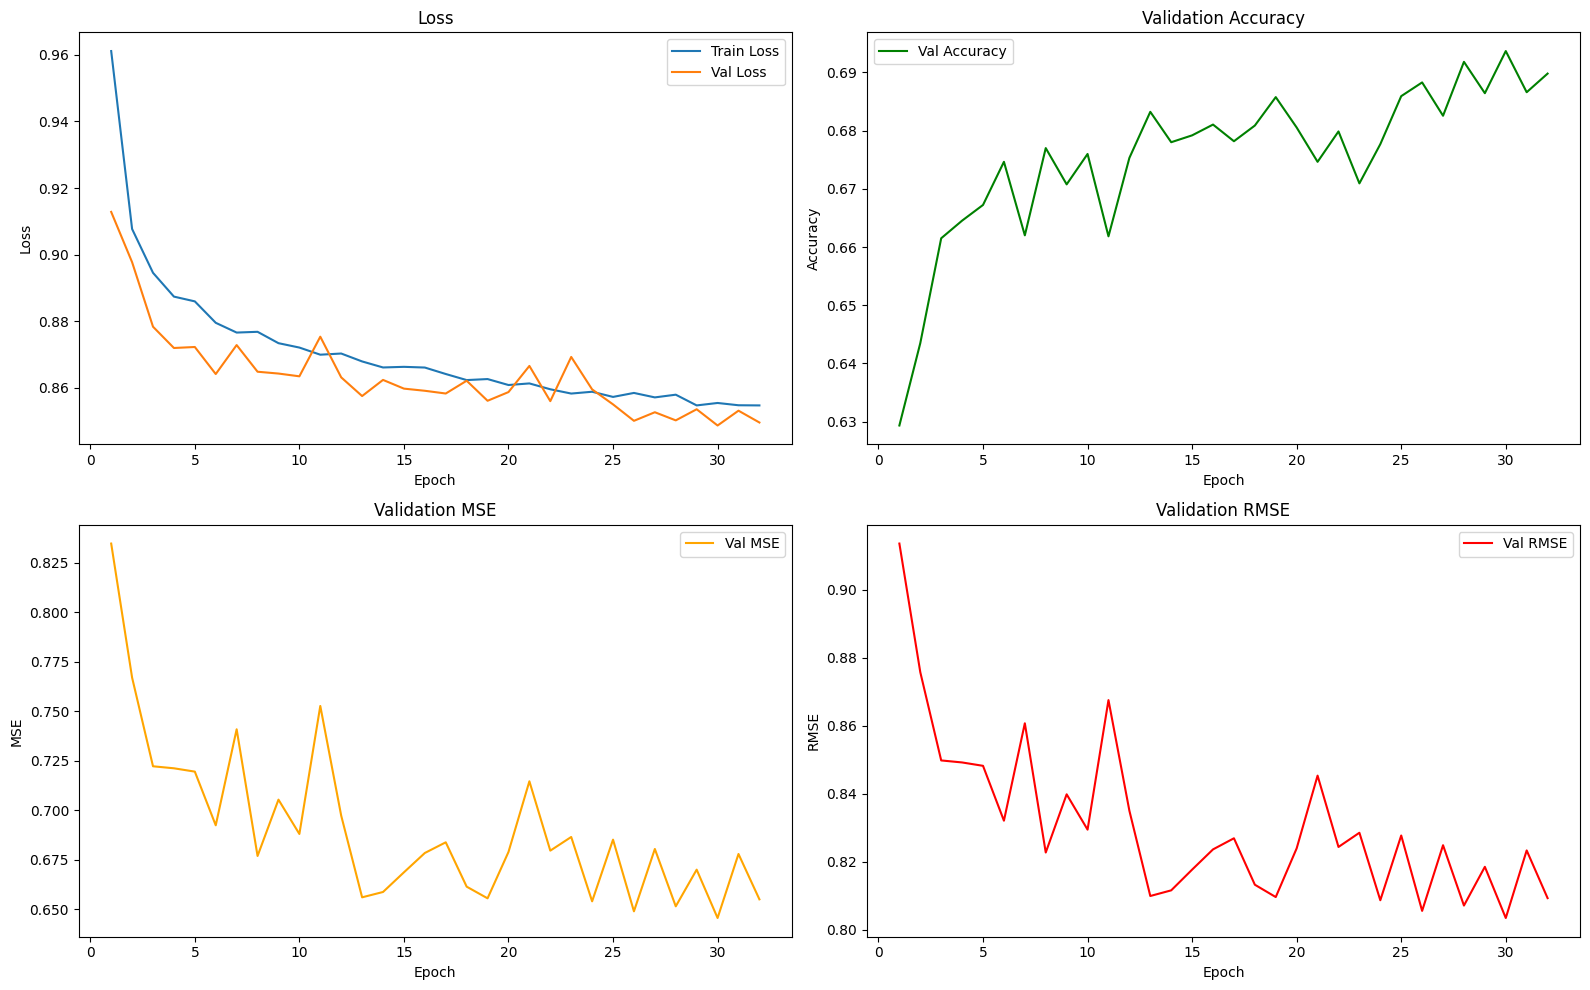

In [19]:
history = train_model(epochs, batch_size, model, train_loader, val_loader)
plot_metrics(history)


Test Loss: 0.8445 | Test Accuracy: 0.6958
Test MAE: 0.4111 |Test MSE: 0.6247 | Test RMSE: 0.7904


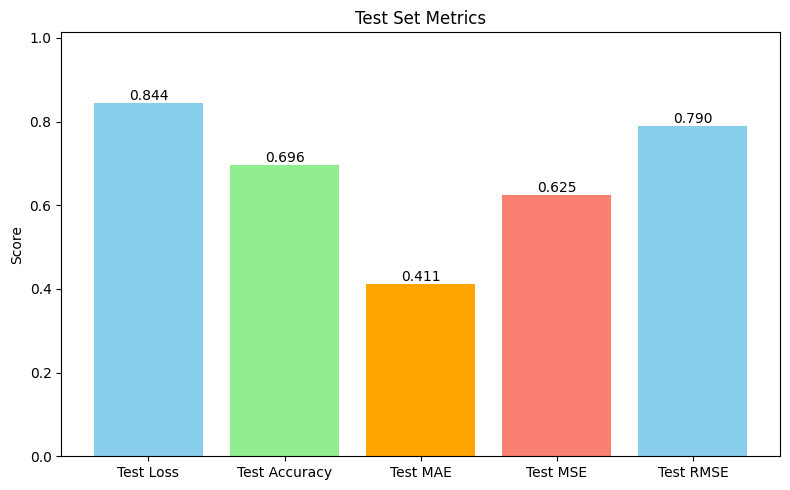

In [34]:
test_metrics = test_model(model, test_loader, nn.CrossEntropyLoss(), device)
plot_test_metrics(test_metrics)

In [35]:
# Save model
torch.save(model.state_dict(), 'eegnet.pth')
# Load model
model.load_state_dict(torch.load('eegnet.pth'))
test_model(model,test_loader,nn.CrossEntropyLoss(),device)
# model.eval()


Test Loss: 0.8445 | Test Accuracy: 0.6958
Test MAE: 0.4111 |Test MSE: 0.6247 | Test RMSE: 0.7904


{'Test Loss': 0.8444667236824241,
 'Test Accuracy': 0.6957547169811321,
 'Test MAE': 0.4110512129380054,
 'Test MSE': 0.6246630727762803,
 'Test RMSE': 0.7903562948292879}

## CNN and LSTM Model

Used Annotations descriptions: [np.str_('T0'), np.str_('T1'), np.str_('T2')]
[np.str_('T0'), np.str_('T1'), np.str_('T2')]
Used Annotations descriptions: [np.str_('T0'), np.str_('T1'), np.str_('T2')]
[np.str_('T0'), np.str_('T1'), np.str_('T2')]
Used Annotations descriptions: [np.str_('T0'), np.str_('T1'), np.str_('T2')]
[np.str_('T0'), np.str_('T1'), np.str_('T2')]
Used Annotations descriptions: [np.str_('T0'), np.str_('T1'), np.str_('T2')]
[np.str_('T0'), np.str_('T1'), np.str_('T2')]
Used Annotations descriptions: [np.str_('T0'), np.str_('T1'), np.str_('T2')]
[np.str_('T0'), np.str_('T1'), np.str_('T2')]
Used Annotations descriptions: [np.str_('T0'), np.str_('T1'), np.str_('T2')]
[np.str_('T0'), np.str_('T1'), np.str_('T2')]
Used Annotations descriptions: [np.str_('T0'), np.str_('T1'), np.str_('T2')]
[np.str_('T0'), np.str_('T1'), np.str_('T2')]
Used Annotations descriptions: [np.str_('T0'), np.str_('T1'), np.str_('T2')]
[np.str_('T0'), np.str_('T1'), np.str_('T2')]
Used Annotations

/var/folders/81/1q27brh54pq12352bbjqkvpr0000gn/T/ipykernel_5048/980650551.py:30: RuntimeWarning: Limited 1 annotation(s) that were expanding outside the data range.
  raw = mne.io.read_raw_edf(edf_path, preload=True, verbose=False)
/var/folders/81/1q27brh54pq12352bbjqkvpr0000gn/T/ipykernel_5048/980650551.py:30: RuntimeWarning: Limited 1 annotation(s) that were expanding outside the data range.
  raw = mne.io.read_raw_edf(edf_path, preload=True, verbose=False)
/var/folders/81/1q27brh54pq12352bbjqkvpr0000gn/T/ipykernel_5048/980650551.py:30: RuntimeWarning: Limited 1 annotation(s) that were expanding outside the data range.
  raw = mne.io.read_raw_edf(edf_path, preload=True, verbose=False)
/var/folders/81/1q27brh54pq12352bbjqkvpr0000gn/T/ipykernel_5048/980650551.py:30: RuntimeWarning: Limited 1 annotation(s) that were expanding outside the data range.
  raw = mne.io.read_raw_edf(edf_path, preload=True, verbose=False)
/var/folders/81/1q27brh54pq12352bbjqkvpr0000gn/T/ipykernel_5048/98065055

Used Annotations descriptions: [np.str_('T0'), np.str_('T1'), np.str_('T2')]
[np.str_('T0'), np.str_('T1'), np.str_('T2')]
Used Annotations descriptions: [np.str_('T0'), np.str_('T1'), np.str_('T2')]
[np.str_('T0'), np.str_('T1'), np.str_('T2')]
Used Annotations descriptions: [np.str_('T0'), np.str_('T1'), np.str_('T2')]
[np.str_('T0'), np.str_('T1'), np.str_('T2')]
Used Annotations descriptions: [np.str_('T0'), np.str_('T1'), np.str_('T2')]
[np.str_('T0'), np.str_('T1'), np.str_('T2')]
Used Annotations descriptions: [np.str_('T0'), np.str_('T1'), np.str_('T2')]
[np.str_('T0'), np.str_('T1'), np.str_('T2')]
Used Annotations descriptions: [np.str_('T0'), np.str_('T1'), np.str_('T2')]
[np.str_('T0'), np.str_('T1'), np.str_('T2')]
Used Annotations descriptions: [np.str_('T0'), np.str_('T1'), np.str_('T2')]
[np.str_('T0'), np.str_('T1'), np.str_('T2')]
Used Annotations descriptions: [np.str_('T0'), np.str_('T1'), np.str_('T2')]
[np.str_('T0'), np.str_('T1'), np.str_('T2')]
Used Annotations

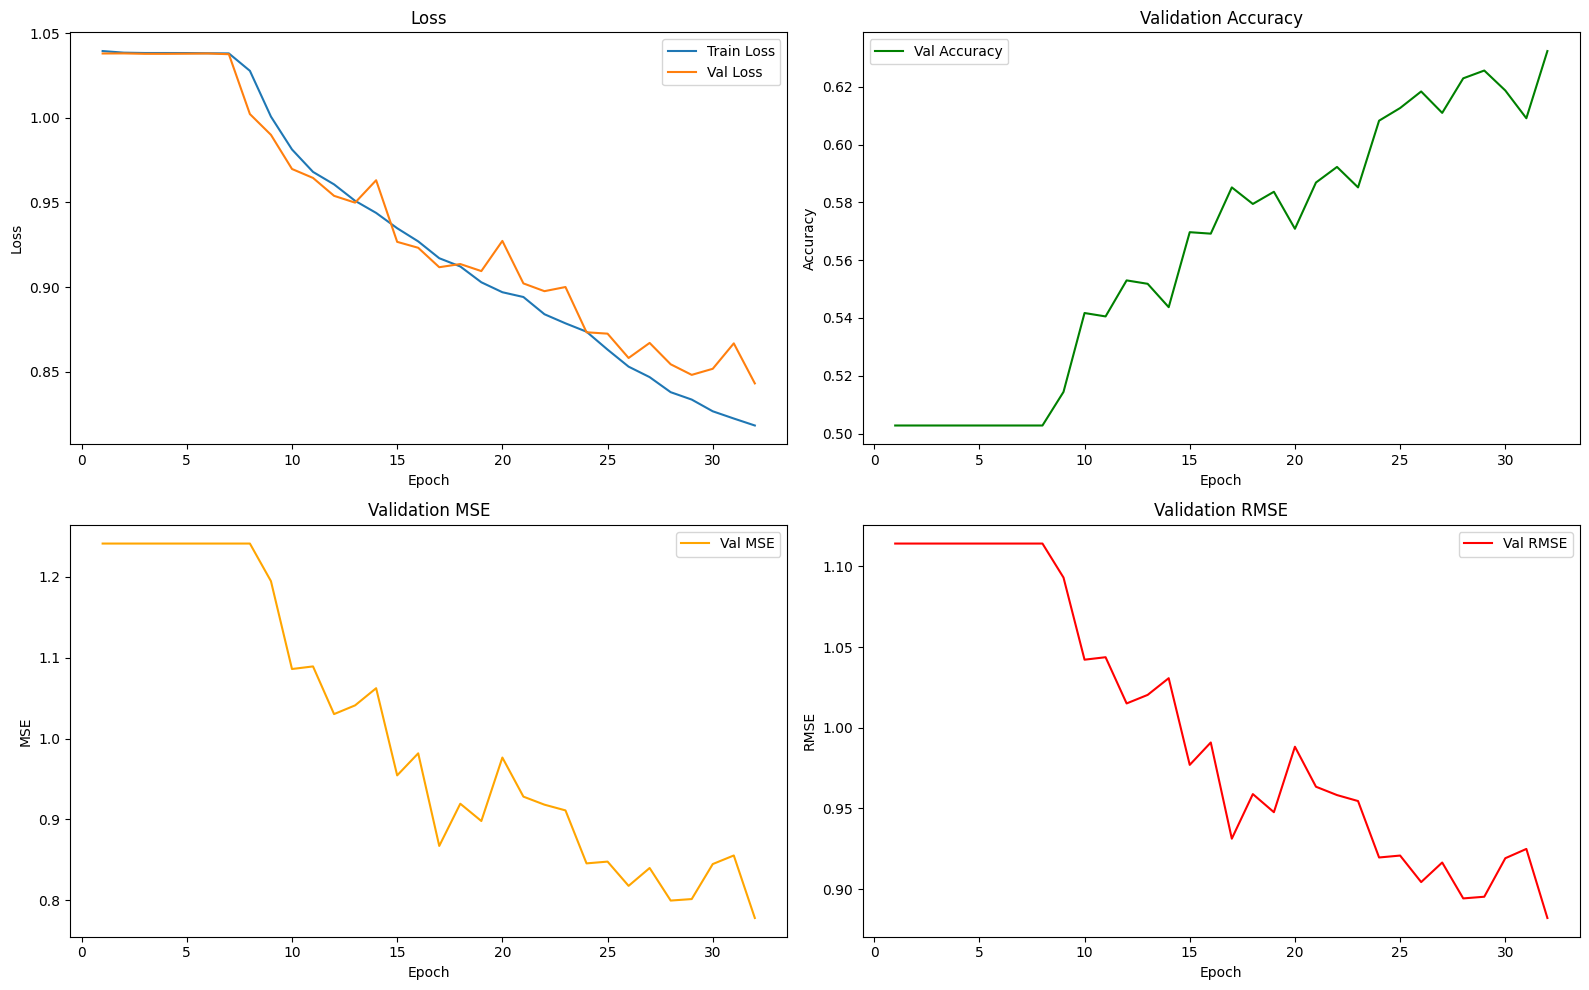


Test Loss: 0.8292 | Test Accuracy: 0.6378
Test MAE: 0.4958 |Test MSE: 0.7630 | Test RMSE: 0.8735


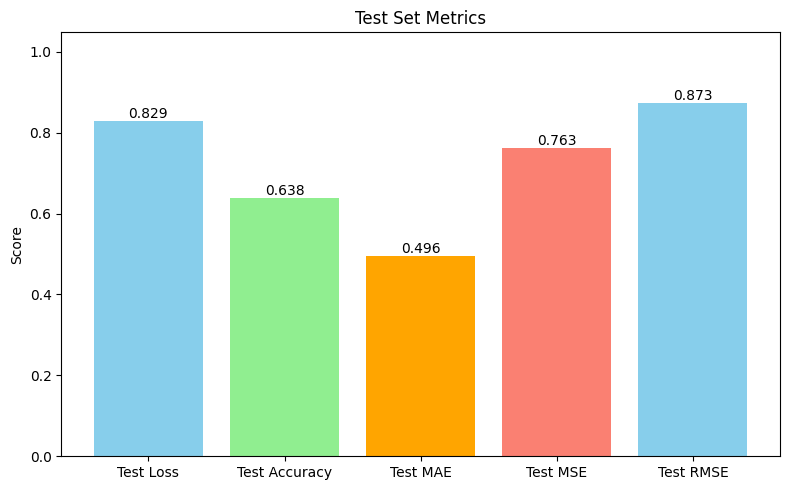

In [36]:
sfreq=128
model = CNN_LSTM(input_size=64, hidden_size=128, num_layers=2, num_classes=3).to(device)
batch_size = 64
epochs = 32
train_loader, val_loader, test_loader = get_loaders(epoch=epochs, batch_size=batch_size, sfreq=sfreq)

history = train_model(epochs, batch_size, model, train_loader, val_loader)
plot_metrics(history)  # 👈 add this line

torch.save(model.state_dict(), 'cstm.pth')
# model.load_state_dict(torch.load('eegnet.pth'))
test_metrics = test_model(model, test_loader, nn.CrossEntropyLoss(), device)
plot_test_metrics(test_metrics)